In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

model = "stg"
with open(fr"{model}_results.pkl", 'rb') as file:
    all_results = pickle.load(file)

if model == "stg":
    lambda_values = np.logspace(-3, 0.3, 10)
    title_string = "STG"
elif model == "lasso":
    title_string = "LASSO"
    lambda_values = np.logspace(-3, -0.5, 10)

num_bins = 10
bin_edges = np.linspace(0, 1250, num_bins + 1)
bin_xticks = []


box_plot_corr = {"full": {}, "100K": {}, "10K": {}}
box_plot_mse = {"full": {}, "100K": {}, "10K": {}}

for read_type in box_plot_corr.keys():
    for bin_idx in range(num_bins):
        box_plot_corr[read_type][bin_idx] = []
        box_plot_mse[read_type][bin_idx] = []

for bin_idx in range(len(bin_edges) - 1):
    bottom = int(bin_edges[bin_idx])
    top = int(bin_edges[bin_idx + 1])
    bin_xticks.append(f"{bottom}-{top}")


In [2]:
exon = '1_9756480_9756511'
lam_idx_val = 1

In [3]:
y_pred_full = [all_results[lam_idx_val][exon][fold_num]['y_pred_full'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]
y_pred_100K = [all_results[lam_idx_val][exon][fold_num]['y_pred_100K'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]
y_pred_10K = [all_results[lam_idx_val][exon][fold_num]['y_pred_10K'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]
y_test = [all_results[lam_idx_val][exon][fold_num]['y_test'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]
y_test_10K = [all_results[lam_idx_val][exon][fold_num]['y_test_10K'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]
y_test_100K = [all_results[lam_idx_val][exon][fold_num]['y_test_100K'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]
test_idxs = [all_results[lam_idx_val][exon][fold_num]['test_idxs'].reshape(-1).tolist() for fold_num in all_results[lam_idx_val][exon].keys()]

y_pred_full = np.concatenate(y_pred_full)
y_pred_100K = np.concatenate(y_pred_100K)
y_pred_10K = np.concatenate(y_pred_10K)
y_test = np.concatenate(y_test)
y_test_10K = np.concatenate(y_test_10K)
y_test_100K = np.concatenate(y_test_100K)
test_idxs = np.concatenate(test_idxs)

y_pred_full = (y_pred_full + 2.5)/ 10
y_pred_100K = (y_pred_100K + 2.5)/ 10
y_pred_10K = (y_pred_10K + 2.5)/ 10
y_test = (y_test + 2.5)/ 10

In [4]:
corr_full = [all_results[5][exon][fold_num]['corr_full'].reshape(-1).tolist() for fold_num in all_results[5][exon].keys()]
corr_100K = [all_results[5][exon][fold_num]['corr_100K'].reshape(-1).tolist() for fold_num in all_results[5][exon].keys()]
corr_10K = [all_results[5][exon][fold_num]['corr_10K'].reshape(-1).tolist() for fold_num in all_results[5][exon].keys()]

mse_full = [all_results[5][exon][fold_num]['mse_full'] for fold_num in all_results[5][exon].keys()]
mse_100K = [all_results[5][exon][fold_num]['mse_100K'] for fold_num in all_results[5][exon].keys()]
mse_10K = [all_results[5][exon][fold_num]['mse_10K'] for fold_num in all_results[5][exon].keys()]

corr_full = np.mean(corr_full)
corr_100K = np.mean(corr_100K)
corr_10K = np.mean(corr_10K)

mse_full = np.mean(mse_full)
mse_100K = np.mean(mse_100K)
mse_10K = np.mean(mse_10K) 

mse_full = (mse_full + 2.5) / 10
mse_100K = (mse_100K + 2.5) / 10
mse_10K = (mse_10K + 2.5) / 10

Bulk 
 Correlation = 0.9078, MSE: 0.4028
100K (Single-Cell) 
 Correlation = 0.8537, MSE: 0.5060
10K 
 Correlation = 0.7086, MSE: 0.7196


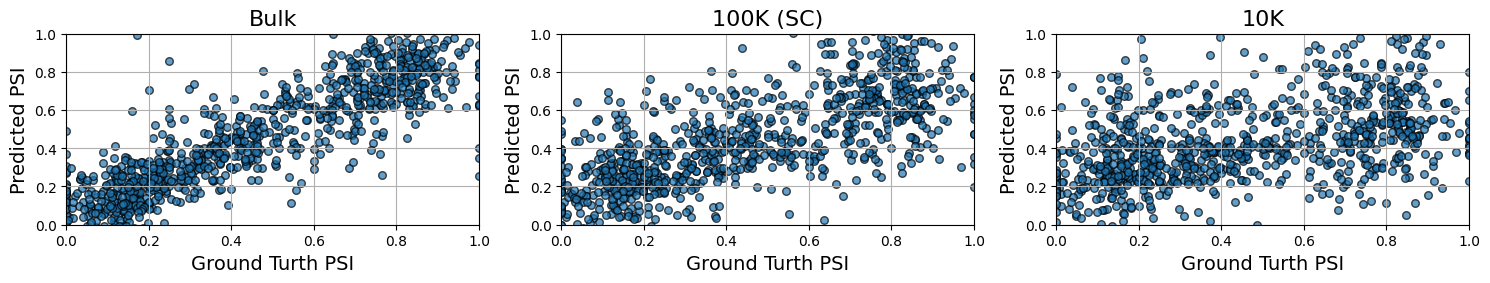

In [ ]:
s = 30
edge_color = "black"
marker = "o"
alpha = 0.7
c='#1f77b4'
xlable_fontsize = 14
ylable_fontsize = 14
title_font = 16
suptitle_font = 18
plt.figure(figsize=(15, 5))
plt.subplot(2, 3, 1)
print(f"Bulk \n Correlation = {corr_full:.4f}, MSE: {mse_full:.4f}")
plt.title(f"Bulk", fontsize=title_font)
plt.xlabel("Ground Turth PSI", fontsize=xlable_fontsize)
plt.ylabel("Predicted PSI", fontsize=ylable_fontsize)
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.grid()
plt.scatter(y_test, y_pred_full, marker=marker,c=c,alpha=alpha,s=s,edgecolor=edge_color,)
plt.subplot(2, 3, 2)
print(f"100K (Single-Cell) \n Correlation = {corr_100K:.4f}, MSE: {mse_100K:.4f}")
plt.title(f"100K (SC)", fontsize=title_font)
plt.xlabel("Ground Turth PSI", fontsize=xlable_fontsize)
plt.ylabel("Predicted PSI", fontsize=ylable_fontsize)
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.grid()
plt.scatter(y_test, y_pred_100K, marker=marker,c=c,alpha=alpha,s=s,edgecolor=edge_color,)
plt.subplot(2, 3, 3)
print(f"10K \n Correlation = {corr_10K:.4f}, MSE: {mse_10K:.4f}")
plt.title(f"10K", fontsize=title_font)
plt.xlabel("Ground Turth PSI", fontsize=xlable_fontsize)
plt.ylabel("Predicted PSI", fontsize=ylable_fontsize)
plt.xlim((0, 1))
plt.ylim((0, 1))
plt.grid()
plt.scatter(y_test, y_pred_10K, marker=marker,c=c,alpha=alpha,s=s,edgecolor=edge_color,)


plt.tight_layout()
plt.savefig("GTEx_PSI_Bulk_100K_10K.png")